In [85]:
from __future__ import annotations

import torch

import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import datasets, transforms

from pathlib import Path
import matplotlib.pyplot as plt

# from torch_tensors_images.py assignment
def get_dataset(root: Path) -> datasets.CIFAR10:
    """
    Returns the CIFAR-10 training set.

    The first time you run this, it will download the dataset to `root`.
    """
    root.mkdir(parents=True, exist_ok=True)
    return datasets.CIFAR10(root=str(root), train=True, download=True, transform=torchvision.transforms.ToTensor())


# define the network
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # conv layer: 
        #   in = 3 since CIFAR-10 images have 3 color channels (RGB)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        # fully connected layers
        self.fc1 = nn.Linear(64 * 2 * 2, 200)
        self.fc2 = nn.Linear(200, 10)

    def forward(self, x):  

        # used the photo's architecture as reference

        # conv1 to relu 
        x = F.relu(self.conv1(x))
        # maxpool(kernel=3, stride=3)
        x = F.max_pool2d(x, kernel_size=3, stride=3)

        # conv2 to relu 
        x = F.relu(self.conv2(x))
        # maxpool(kernel=2, stride=2)
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = x.view(x.size(0), -1) 

        # fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x



    # data_root = Path(__file__).resolve().parent / "data"

    # copied the dataset into the root of the project
data_root = Path("./data") # alt way since it kept saying __file__ is not defined
dataset = get_dataset(data_root)
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)
images, labels = next(iter(data_loader))
# Create network
net = Net()
# Forward pass
output = net(images)
print(f"Input tensor shape: {images.shape}")    # [64, 3, 32, 32]
print(f"Output tensor shape: {output.shape}")   # [64, 10]
optimizer = torch.optim.Adam(net.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss() # another name for loss function
# training loop
for epoch in range(5): # outer for loop layer for reshuffling
    for images, labels  in data_loader: # inner loop for training
        optimizer.zero_grad()
        output = net(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch + 1}, loss: {loss.item():.4f}")    

Files already downloaded and verified
Input tensor shape: torch.Size([64, 3, 32, 32])
Output tensor shape: torch.Size([64, 10])
Epoch 1, loss: 1.9068


KeyboardInterrupt: 

In [ ]:
test_dataset = datasets.CIFAR10(root=str(data_root), train=False, download=True, transform=torchvision.transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=10, shuffle=False)


images, labels = next(iter(test_loader))
logits = net(images)
probabilities = F.softmax(logits, dim=1)
predicted_classes = torch.argmax(probabilities, dim=1)
print(f"Predicted classes: {predicted_classes}\n", f"True labels: {labels}")

Files already downloaded and verified
Predicted classes: tensor([3, 1, 8, 0, 6, 6, 5, 6, 3, 1])
 True labels: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1])


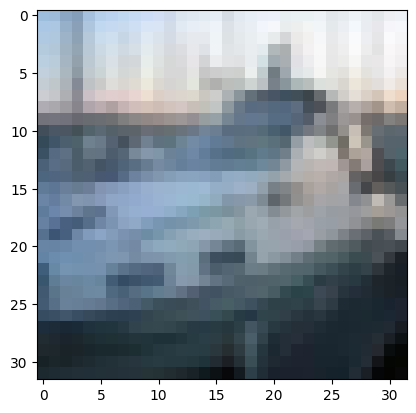

In [ ]:
images = images[2].unsqueeze(0)
plt.imshow(images.squeeze().permute(1, 2, 0))

In [ ]:
dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
confusion_matrix = torch.zeros(10, 10)
with torch.no_grad():
    for images, labels in test_loader:
        logits = net(images)
        probabilities = F.softmax(logits, dim=1)
        predicted_classes = torch.argmax(probabilities, dim=1)
        for t, p in zip(labels.view(-1), predicted_classes.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
tensor([[574.,  31.,  59.,  39.,  91.,   3.,  17.,  33.,  91.,  62.],
        [ 22., 651.,   2.,  21.,  17.,   4.,  22.,  16.,  44., 201.],
        [ 46.,  11., 321., 119., 225.,  58.,  95.,  90.,  19.,  16.],
        [  8.,  10.,  32., 473., 142., 122.,  80.,  93.,  10.,  30.],
        [ 12.,   2.,  30.,  67., 635.,  20.,  74., 133.,  12.,  15.],
        [  5.,   4.,  29., 271., 118., 402.,  28., 123.,   4.,  16.],
        [  3.,   6.,  22.,  90.,  81.,  10., 754.,  19.,   1.,  14.],
        [  8.,   1.,   6.,  56., 111.,  46.,  10., 731.,   5.,  26.],
        [103.,  28.,   5.,  38.,  33.,   7.,   9.,  12., 673.,  92.],
        [ 19.,  58.,   2.,  36.,  17.,   8.,  12.,  36.,  28., 784.]])


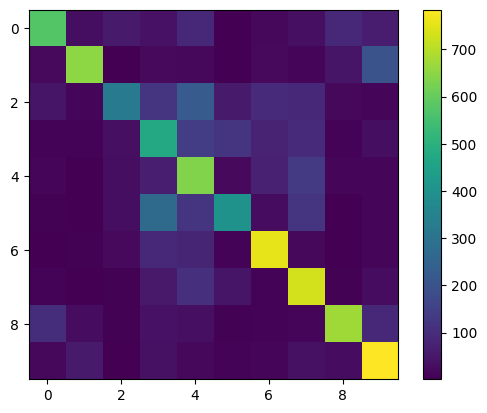

In [ ]:
plt.imshow(confusion_matrix)
plt.colorbar()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6403836..0.55990285].


Original image shape: torch.Size([3, 32, 32])
New image shape: torch.Size([1, 3, 64, 64])


Text(0.5, 1.0, 'Transposed Convolution Image')

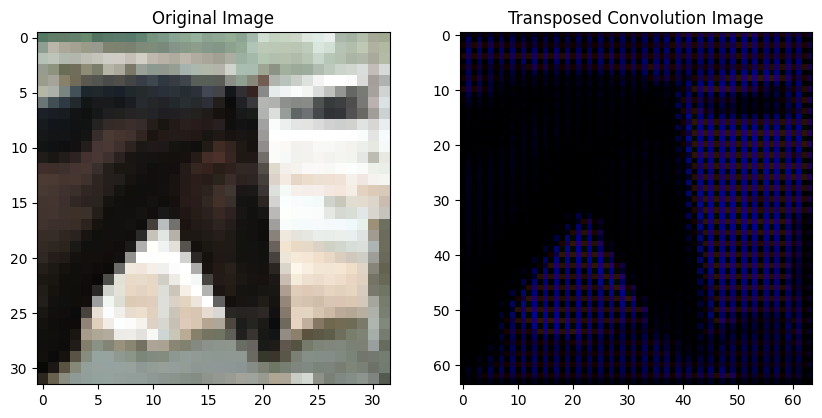

In [ ]:
image = images[0]
tr_conv = nn.ConvTranspose2d(in_channels = 3, out_channels = 3, kernel_size = 3, stride = 2, padding = 1, output_padding = 1)

new_image = tr_conv(image.unsqueeze(0))
print(f"Original image shape: {image.shape}")  # [1, 3, 32, 32]
print(f"New image shape: {new_image.shape}")  # [1, 3, 64, 64]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().permute(1, 2, 0))
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(new_image.squeeze().permute(1, 2, 0).detach().numpy())
plt.title("Transposed Convolution Image")



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022559136..1.0788761].


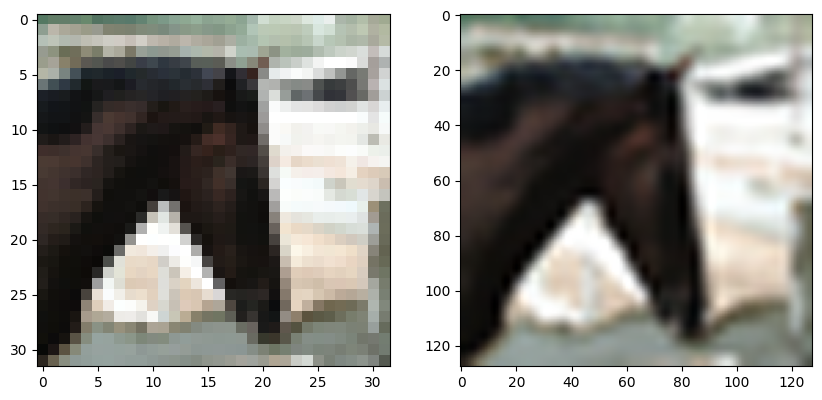

In [ ]:
new_image = F.interpolate(image.unsqueeze(0), scale_factor=4, mode='bicubic')
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(new_image.squeeze().permute(1, 2, 0).detach().numpy())
